### Skewness and halo mass function correction from lim.py

In [1]:
import sys
code_dir = '/mnt/DATA/coding/21cm/fnl/lim'
sys.path.insert(0, str(code_dir))
code_dir = '/mnt/DATA/coding/21cm/fnl/lim/source'
sys.path.insert(0, str(code_dir))

import astropy.units as u
from lim import lim 
from line_model import * 
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams.update({"text.usetex": True, "font.family": "Times new roman"}) # Use latex fonts
colors =  ['#377eb8', '#ff7f00', '#4daf4a',
           '#f781bf', '#a65628', '#984ea3',
           '#999999', '#e41a1c', '#dede00']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors) # Set the color palette as default


In [2]:
cosmo_params_fNL = {"hlittle": 0.6727, # hubble parameter
                "OMb": 0.02236/0.6727**2, # baryon density
                "OMm": 0.1202/0.6727**2, # matter (CDM+baryon) density
                "A_s": 2.101e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":100., # to test matching with old case
                "ANALYTICAL_DER_TPF":True}

In [3]:
par = dict(model_type = 'ML',
            nu=115*u.GHz,
            nuObs=115*u.GHz, # to get z = 0!
           model_name='TonyLi',
           hmf_model='ST',
            cosmo_code ='class',
            cosmo_input_class=dict(f_NL=cosmo_params_fNL['F_NL'], 
            k_pivot = 0.05,
            H0=cosmo_params_fNL['hlittle']*100.,
            omega_b=cosmo_params_fNL['OMb']*cosmo_params_fNL['hlittle']**2, 
            omega_cdm=(cosmo_params_fNL['OMm']-cosmo_params_fNL['OMb'])*cosmo_params_fNL['hlittle']**2, 
            A_s=cosmo_params_fNL['A_s'],
            n_s=cosmo_params_fNL['POWER_INDEX'],
            output='mPk,mTk'),Mmin=1e5*u.Msun)

use_lim = lim(par)

par_cutoff = dict(model_type = 'ML',
           model_name='TonyLi',
           hmf_model='ST',
            nu=115*u.GHz,
            nuObs=115*u.GHz,
            cosmo_code ='class',
            cosmo_input_class=dict(f_NL=cosmo_params_fNL['F_NL'], 
            k_pivot = 0.05,
            H0=cosmo_params_fNL['hlittle']*100.,
            omega_b=cosmo_params_fNL['OMb']*cosmo_params_fNL['hlittle']**2, 
            omega_cdm=(cosmo_params_fNL['OMm']-cosmo_params_fNL['OMb'])*cosmo_params_fNL['hlittle']**2, 
            A_s=cosmo_params_fNL['A_s'],
            n_s=cosmo_params_fNL['POWER_INDEX'],
            output='mPk,mTk'),Mmin=1e5*u.Msun,klim=1e-1)

use_lim_cutoff = lim(par_cutoff)

Compute:

- dn3_J = $\langle\delta_n^3\rangle$, der_dn3_J = $\dfrac{d\langle\delta_n^3\rangle}{dM_n}$

- k3_J = $\kappa_3 = \dfrac{\langle\delta_n^3\rangle}{\sigma_N^3}$, der_k3 = $\dfrac{d\kappa_3}{dM_n}$

- corr_J = $\dfrac{n_{\rm NG}}{n_{\rm G}}$ -- THIS IS THE NON GAUSS - GAUSS HMF correction!

In [4]:
use_M = use_lim.M.value

In [5]:
dn3_J, der_dn3_J = use_lim.S3_dS3
k3_J, der_k3_J = use_lim.kappa3_dkappa3dM
corr_J = use_lim.Delta_HMF

In [6]:
dn3_J_cutoff, der_dn3_J_cutoff = use_lim_cutoff.S3_dS3
k3_J_cutoff, der_k3_J_cutoff = use_lim_cutoff.kappa3_dkappa3dM
corr_J_cutoff = use_lim_cutoff.Delta_HMF

### Comparison with my implementation

In [5]:
from scipy.interpolate import interp1d
import numpy as np 
from classy import Class
from scipy.interpolate import CubicSpline

First, let's run CLASS and extract the transfer function.

In [6]:
# Set CLASS parameters

h = cosmo_params_fNL['hlittle']
As = cosmo_params_fNL['A_s']
Omega_b0 = cosmo_params_fNL['OMb']
Omega_m0 = cosmo_params_fNL['OMm']
ns = cosmo_params_fNL['POWER_INDEX']
Omega_c0 = Omega_m0 - Omega_b0 # CDM portion
Omega_Lambda = 1. - Omega_m0 # Dark energy portion
Tcmb0 = 2.728 # CMB temperature in K


CLASS_params = {}
CLASS_params['h'] = h
CLASS_params['Omega_cdm'] = Omega_c0
CLASS_params['Omega_b'] = Omega_b0
CLASS_params['n_s'] = ns
CLASS_params['A_s'] = As
CLASS_params['T_cmb'] = Tcmb0
CLASS_params['m_ncdm'] = "0.06" # eV
CLASS_params['N_ncdm'] = 1
CLASS_params['N_ur'] = 2.0308
CLASS_params['output'] = 'tCl,lCl,mTk,mPk'
CLASS_params['lensing'] = 'yes'
CLASS_params['z_pk'] = 1050.
# We need to run CLASS for very large wavenumbers. This is required for computing sigma(M) and the HMF
CLASS_params['P_k_max_1/Mpc'] = 3000.

def Interpolate_transfer(T_CLASS,k_CLASS,k_output):
    # Interpolate the trnasfer function at k_output
    Transfer_interp = interp1d(k_CLASS, T_CLASS, kind='cubic',
                                bounds_error=False,fill_value=0.)
    Transfer = Transfer_interp(k_output)
    # If necessary, extrapolate the transfer function beyond its extent
    # (in a power-law fashion)
    if max(k_output) > max(k_CLASS):
        ind = np.where(k_output > k_CLASS[-1])[0][0] - 1
        if (abs(Transfer[ind]) > 0.) and (abs(Transfer[ind-1]) > 0.):
            slope = np.log(Transfer[ind]/Transfer[ind-1])/np.log(k_output[ind]/k_output[ind-1])
            Transfer[ind:] = Transfer[ind]*pow((k_output[ind:]/k_output[ind]),slope)
    if min(k_output) < min(k_CLASS):
        ind = np.where(k_output < k_CLASS[0])[0][-1] + 1
        if (abs(Transfer[ind]) > 0.) and (abs(Transfer[ind+1]) > 0.):
            slope = np.log(Transfer[ind]/Transfer[ind+1])/np.log(k_output[ind]/k_output[ind+1])
            Transfer[:ind] = Transfer[ind]*pow((k_output[:ind]/k_output[ind]),slope)
    # Return output
    return (Transfer)

CLASS_OUTPUT = Class()
CLASS_OUTPUT.set(CLASS_params)
CLASS_OUTPUT.compute()

#k_output = use_lim.k
#LOG_K_ARR_FOR_TRANSFERS = np.linspace(-10,4,144)
LOG_K_ARR_FOR_TRANSFERS = [-5.15144838, -5.0514484 , -4.95144828, -4.85144824, -4.75144831,
                                         -4.65144846, -4.55144842, -4.45144844, -4.35144836, -4.2514484 ,
                                         -4.15144838, -4.0514484 , -3.95144828, -3.85144824, -3.75144831,
                                         -3.65144846, -3.55144842, -3.45144844, -3.35144836, -3.2514484 ,
                                         -3.15144838, -3.0514484 , -2.95144828, -2.85144824, -2.75144831,
                                         -2.65144846, -2.55144842, -2.45144844, -2.35144836, -2.2514484 ,
                                         -2.15144838, -2.0514484 , -1.95144828, -1.85144855, -1.75145051,
                                         -1.65167858, -1.55757323, -1.49148227, -1.44915893, -1.41712202,
                                         -1.39038991, -1.36686022, -1.34546231, -1.3255776 , -1.30681547,
                                         -1.28891354, -1.27168632, -1.25499794, -1.23874561, -1.22284979,
                                         -1.20724751, -1.19188819, -1.17673058, -1.1617405 , -1.14688964,
                                         -1.13215425, -1.11751423, -1.1029525 , -1.08845468, -1.07400858,
                                         -1.05960376, -1.04523159, -1.0308847 , -1.01655703, -1.00224362,
                                         -0.98794056, -0.97364449, -0.95935297, -0.9450646 , -0.93077752,
                                         -0.91649165, -0.90220562, -0.88792009, -0.87363446, -0.85934868,
                                         -0.84506291, -0.83077684, -0.81649043, -0.80220246, -0.78791232,
                                         -0.7736182 , -0.75931799, -0.74500867, -0.73068674, -0.71634763,
                                         -0.70198555, -0.6875937 , -0.67316396, -0.65868698, -0.64415096,
                                         -0.6295428 , -0.61484684, -0.60004451, -0.58511402, -0.57002998,
                                         -0.5547616 , -0.53927245, -0.5235185 , -0.50744591, -0.49098831,
                                         -0.47406185, -0.45656015, -0.43834405, -0.41922757, -0.39895473,
                                         -0.3771609 , -0.35330423, -0.32653792, -0.29545819, -0.25758495,
                                         -0.20836373, -0.14039666, -0.05026523,  0.04900858,  0.1489976 ,
                                         0.24899768,  0.34899762,  0.44899771,  0.54899762,  0.64899771,
                                         0.7489977 ,  0.84899769,  0.94899765,  1.04899772,  1.1489976 ,
                                         1.24899768,  1.34899762,  1.44899771,  1.54899762,  1.64899771,
                                         1.7489977 ,  1.84899769,  1.94899765,  2.04899772,  2.1489976 ,
                                         2.24899768,  2.34899762,  2.44899771,  2.54899762,  2.64899771,
                                         2.7489977 ,  2.84899769,  2.94899765,  3.04899772]

k_output = pow(10.,np.array(LOG_K_ARR_FOR_TRANSFERS)) # 1/Mpc

T = CLASS_OUTPUT.get_transfer(0.,'camb')
k_CLASS = T['k (h/Mpc)']*cosmo_params_fNL['hlittle']
delta_zeta_0_CLASS = T['-T_tot/k2']

T_ZETA_TRANSFER = Interpolate_transfer(delta_zeta_0_CLASS,k_CLASS,k_output)


# Transfer_0 = CLASS_OUTPUT.get_transfer(0.,'camb')
# k_CLASS = Transfer_0['k (h/Mpc)'][:]*h # 1/Mpc
# delta_zeta_0_CLASS = Transfer_0['-T_tot/k2']
# # Interpolate the matter transfer function at the desired wavenumbers
# delta_zeta_0 = Interpolate_transfer(delta_zeta_0_CLASS,k_CLASS,k_output)
# T_ZETA_TRANSFER = list(delta_zeta_0)

Define the real-space tophat window function and its derivative.

Introduce their product with the transfer function:

$R = (3M_h/(4\pi\rho_m))^{1/3}$

$\mathcal{M}(k,M) = \dfrac{T_\zeta k^2}{T_\Phi}W(kR)$

$\dfrac{d\mathcal{M}(k,M)}{dM} = \dfrac{T_\zeta k^2}{T_\Phi}\dfrac{dW(kR)}{dM}$

In [7]:
def window(k,M,rhoM):

    R = (3.*M/(4.*np.pi*rhoM))**(1/3.)

    x = (k*R)
    W = 3.0*(np.sin(x) - x*np.cos(x))/(x)**3 

    return W

def der_window(k,M,rhoM):

    R = (3.*M/(4.*np.pi*rhoM))**(1/3.)
    
    x = (k*R)

    dW_dM = (-9*np.sin(x) + 9*x*np.cos(x) + 3*(x**2)*np.sin(x))/((3*M)*(x**3))

    return dW_dM

def curlM(k,M,kall,cosmo_params, T_ZETA_TRANSFER,CLASS):
    
    T_CLASS = interp1d(kall, T_ZETA_TRANSFER, kind='cubic', bounds_error=False,fill_value=0.)

    rho_crit = 2.7754e11 * cosmo_params['hlittle']**2
    rhoM = rho_crit *cosmo_params['OMm']


    Tphi = 3/5.

    curlM = (T_CLASS(k)*k**2/Tphi) * window(k,M,rhoM)

    return curlM


def der_curlM(k,M,kall,cosmo_params,T_ZETA_TRANSFER,CLASS):
    
    T_CLASS = interp1d(kall, T_ZETA_TRANSFER, kind='cubic', bounds_error=False,fill_value=0.)

    rho_crit = 2.7754e11 * cosmo_params['hlittle']**2
    rhoM = rho_crit * cosmo_params['OMm']
    Tphi = 3/5.

    dcurlM = (T_CLASS(k)*k**2/Tphi) * der_window(k,M,rhoM)

    return dcurlM

Define the primordial potential transfer function 

In [8]:
def Pphi(k, cosmo_params):

    Tphi = 3/5.
    P = Tphi**2 *cosmo_params['A_s'] * pow(k/0.05, cosmo_params['POWER_INDEX']-1) * (2*np.pi**2/k**3) 
    
    return P

Compute the three point function matrix 

In [9]:
def FM(kall,k_1,Mm,k_class,cosmo_params,T_ZETA_TRANSFER,CLASS):

    mu = np.linspace(-0.995, 0.995, 128) # cos theta

    if type(k_1) == np.float64:
        if type(Mm) == np.float64:
            k_2 = kall[:, None]
            mu_val = mu[None,:]
        else:
            Mm = Mm[None,None,:]
            k_2 = kall[:, None,None]
            mu_val = mu[None,:,None]

        integrate_k2 = 0
        integrate_mu = 1

    else:
        if type(Mm) == np.float64:
            k_1 = k_1[:,None, None]
            k_2 = kall[None,:,None]
            mu_val = mu[None,None,:]
        else:
            Mm = Mm[None,None, None,:]
            k_1 = k_1[:,None, None,None]
            k_2 = kall[None,:, None,None]
            mu_val = mu[None,None,:,None]

        integrate_k2 = 1
        integrate_mu = 2

    Pphi_1 = Pphi(k_1,cosmo_params)
    Pphi_2 = Pphi(k_2,cosmo_params)

    k_12 = np.sqrt(pow(k_1,2)+pow(k_2,2) + 2*k_1*k_2*mu_val)

    curlM_2 = curlM(k_2,Mm,k_class,cosmo_params,T_ZETA_TRANSFER,CLASS) 
    curlM_12 = curlM(k_12,Mm,k_class,cosmo_params,T_ZETA_TRANSFER,CLASS) 

    if cosmo_params['ANALYTICAL_DER_TPF']:
        der_curlM_2 = der_curlM(k_2,Mm,k_class,cosmo_params,T_ZETA_TRANSFER,CLASS) 
        der_curlM_12 = der_curlM(k_12,Mm,k_class,cosmo_params,T_ZETA_TRANSFER,CLASS) 

    integrand = k_2**2 * curlM_2 * curlM_12 * (Pphi_1 * Pphi_2 )
    
    integral_dk2 = np.trapz(integrand, mu, axis = integrate_mu)
    Fm = np.trapz(integral_dk2, kall, axis = integrate_k2)

    Fm *= 6. * cosmo_params['F_NL'] / (8*np.pi**4.) 

    if cosmo_params['ANALYTICAL_DER_TPF']:
        integrand_dn2 = k_2**2 * (Pphi_1 * Pphi_2 ) * (der_curlM_2 * curlM_12 + curlM_2 * der_curlM_12)
        
        integral_dk2_dn2 = np.trapz(integrand_dn2, mu, axis = integrate_mu)
        dFm_dn2 = np.trapz(integral_dk2_dn2, kall, axis = integrate_k2)
        
        dFm_dn2 *= 6. * cosmo_params['F_NL'] / (8*np.pi**4.) 

        return Fm, dFm_dn2

    else:
        return Fm  
    

def tpf(log10_mass_array,cosmo_params,kcutoff,T_ZETA_TRANSFER,CLASS):

    print('Computing three point functions to estimate the Fcoll NG corrections...')

    MassVector = pow(10, log10_mass_array)

    kall_full = pow(10.,np.array(LOG_K_ARR_FOR_TRANSFERS)) # 1/Mpc
    kall = np.asarray(kall_full[[kall_full > kcutoff][0]])
    
    k_1 = kall[:,None,None]

    Mn = MassVector[None,:,None]

    curlM_1 = curlM(k_1,Mn,kall_full,cosmo_params,T_ZETA_TRANSFER,CLASS) 

    if cosmo_params['ANALYTICAL_DER_TPF']:
        Fmv, dFm_dn2v = FM(kall,kall, MassVector,kall_full,cosmo_params,T_ZETA_TRANSFER,CLASS)
        Fm = Fmv[:,None,:]
        dFm_dn2 = dFm_dn2v[:,None,:]
        der_curlM_1 = der_curlM(k_1,Mn,kall_full,cosmo_params,T_ZETA_TRANSFER,CLASS) 
    else:
        Fmv = FM(kall,kall, MassVector,kall_full,cosmo_params,T_ZETA_TRANSFER,CLASS)
        Fm = Fmv[:,None,:]

    integrand = k_1** 2 * curlM_1 * Fm

    ddd = np.trapz(integrand,kall,axis=0)

    if cosmo_params['ANALYTICAL_DER_TPF']:
        integrand_dnm2 = k_1** 2 * der_curlM_1 * Fm
        integrand_dmn2 = k_1** 2 * curlM_1 * dFm_dn2
        integrand_dn3 = k_1** 2 * (der_curlM_1 * Fm + curlM_1 * dFm_dn2)

        der_dnm2 = np.trapz(integrand_dnm2,kall,axis=0)
        der_dmn2 = np.trapz(integrand_dmn2,kall,axis=0)
        der_dn3 = np.trapz(integrand_dn3,kall,axis=0)

        return ddd, der_dn3, der_dmn2, der_dnm2
    else:

        return ddd


In [10]:
log10_M_array = np.linspace(4.,20.,300)

In [11]:

ddd, der_dn3, der_dmn2, der_dnm2 = tpf(log10_M_array,cosmo_params_fNL,kcutoff=1e-3,T_ZETA_TRANSFER=T_ZETA_TRANSFER,CLASS=CLASS_OUTPUT)

ddd_flattened = list(ddd.flatten())
der_dn3_flattened = list(der_dn3.flatten())
der_dnm2_flattened = list(der_dnm2.flatten())
der_dmn2_flattened = list(der_dmn2.flatten())

Computing three point functions to estimate the Fcoll NG corrections...


In [12]:
ddd_cutoff, der_dn3_cutoff, der_dmn2_cutoff, der_dnm2_cutoff = tpf(log10_M_array,cosmo_params_fNL,kcutoff=1e-1,T_ZETA_TRANSFER=T_ZETA_TRANSFER,CLASS=CLASS_OUTPUT)

ddd_flattened_cutoff = list(ddd_cutoff.flatten())
der_dn3_flattened_cutoff = list(der_dn3_cutoff.flatten())
der_dnm2_flattened_cutoff = list(der_dnm2_cutoff.flatten())
der_dmn2_flattened_cutoff = list(der_dmn2_cutoff.flatten())

Computing three point functions to estimate the Fcoll NG corrections...


Define interpolation

In [12]:
def three_point_interpolations(Mn, Mm, tp):
    """
    2D linear interpolation of the three-point function in log10(Mn), log10(Mm).
    """

    # Convert to log10
    log_Mn = np.log10(Mn)
    log_Mm = np.log10(Mm)

    logM_arr = list(log10_M_array)
    npts = len(log10_M_array)

    # Bounds checking for Mn
    if log_Mn < logM_arr[0]:
        raise ValueError(
            f"Attempted to compute three point function for Mn={Mn:e}, "
            f"but minimum M in the interpolation table is {10**logM_arr[0]:e}"
        )
    elif log_Mn > logM_arr[npts - 1]:
        raise ValueError(
            f"Attempted to compute three point function for Mn={Mn:e}, "
            f"but maximum M in the interpolation table is {10**logM_arr[npts - 1]:e}"
        )

    # Bounds checking for Mm
    if log_Mm < logM_arr[0]:
        raise ValueError(
            f"Attempted to compute three point function for Mm={Mm:e}, "
            f"but minimum M in the interpolation table is {10**logM_arr[0]:e}"
        )
    elif log_Mm > logM_arr[npts - 1]:
        raise ValueError(
            f"Attempted to compute three point function for Mm={Mm:e}, "
            f"but maximum M in the interpolation table is {10**logM_arr[npts - 1]:e}"
        )

    # Grid spacing (assumed uniform)
    dlog10_M = logM_arr[1] - logM_arr[0]

    # Find lower indices
    Mn_ind = int(np.floor((log_Mn - logM_arr[0]) / dlog10_M))
    Mm_ind = int(np.floor((log_Mm - logM_arr[0]) / dlog10_M))

    # Clamp indices to stay within bounds for +1 access
    if Mn_ind == npts - 1:
        Mn_ind -= 1
    if Mm_ind == npts - 1:
        Mm_ind -= 1

    # Neighbouring grid points
    log_Mn1 = logM_arr[Mn_ind]
    log_Mn2 = logM_arr[Mn_ind + 1]
    log_Mm1 = logM_arr[Mm_ind]
    log_Mm2 = logM_arr[Mm_ind + 1]

    dnn = tp[Mm_ind     + npts * Mn_ind]
    dnm = tp[Mm_ind     + npts * (Mn_ind + 1)]
    dmn = tp[Mm_ind + 1 + npts * Mn_ind]
    dmm = tp[Mm_ind + 1 + npts * (Mn_ind + 1)]

    # 2D linear interpolation
    dd1 = (dmn * (log_Mm - log_Mm1) + dnn * (log_Mm2 - log_Mm)) / (log_Mm2 - log_Mm1)
    dd2 = (dmm * (log_Mm - log_Mm1) + dnm * (log_Mm2 - log_Mm)) / (log_Mm2 - log_Mm1)

    ddd = (dd2 * (log_Mn - log_Mn1) + dd1 * (log_Mn2 - log_Mn)) / (log_Mn2 - log_Mn1)

    return ddd


In [18]:
use_d3 = np.zeros(len(use_M))
use_d3_cutoff = np.zeros(len(use_M))
use_der_d3 = np.zeros(len(use_M))
use_der_d3_cutoff = np.zeros(len(use_M))
for i in range(len(use_M)):
    use_d3[i] = three_point_interpolations(use_M[i],use_M[i],ddd_flattened)
    use_d3_cutoff[i] = three_point_interpolations(use_M[i],use_M[i],ddd_flattened_cutoff)

    use_der_d3[i] = three_point_interpolations(use_M[i],use_M[i],der_dn3_flattened)
    use_der_d3_cutoff[i] = three_point_interpolations(use_M[i],use_M[i],der_dn3_flattened_cutoff)

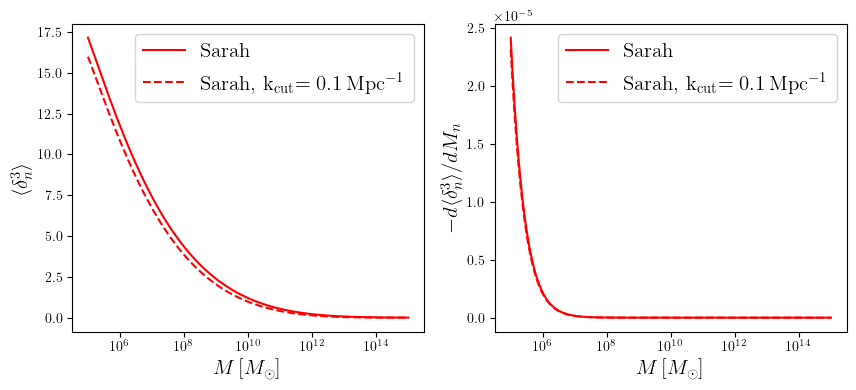

In [20]:
plt.figure(figsize=(10,4))
plt.subplot(121)
# plt.semilogx(use_M,dn3_J,'k',label=r'$\rm lim.py$')
# plt.semilogx(use_M,dn3_J_cutoff,'k--',label=r'$\rm lim.py,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.semilogx(use_M,use_d3,'r',label=r'$\rm Sarah$')
plt.semilogx(use_M,use_d3_cutoff,'r--',label=r'$\rm Sarah,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$\langle\delta_n^3\rangle$',fontsize=15)
plt.legend(fontsize=15)

plt.subplot(122)
# plt.loglog(use_M,-der_dn3_J,'k',label=r'$\rm lim.py$')
# plt.loglog(use_M,-der_dn3_J_cutoff,'k--',label=r'$\rm lim.py,\,k_{\rm cut}={0.1\,Mpc}^{-1}$')
plt.semilogx(use_M,-use_der_d3,'r',label=r'$\rm Sarah$')
plt.semilogx(use_M,-use_der_d3_cutoff,'r--',label=r'$\rm Sarah,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$-d\langle\delta_n^3\rangle/dM_{n}$',fontsize=15)
plt.legend(fontsize=15)

Define $\sigma(M,z)$ and its derivative wrt the mass.

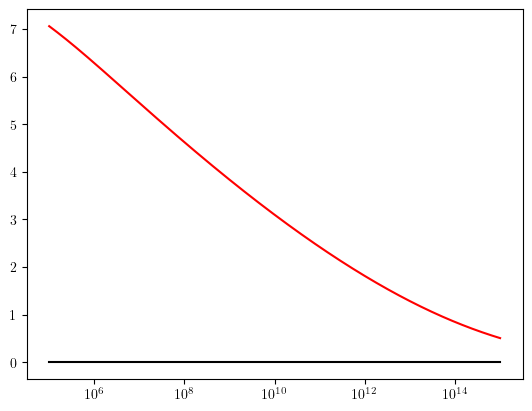

In [13]:
def sigma_Mz(Mh,z,cosmo_params,CLASS, how='CLASS'):

    rho_crit = 2.7754e11 * cosmo_params['hlittle']**2
    rhoM = rho_crit * (CLASS.Omega0_m()-CLASS.Omega_nu)
    if how == 'CLASS':

        R = pow(Mh*3./4./np.pi/Omega_m0/rho_crit,1./3.)

        sigma = CLASS.sigma(R,z)

    else:
        W = window(k_output,Mh,rhoM)
        
        #Compute sigma(M)
        Pk = CLASS.get_pk_cb_array(k_output,np.array([z]),len(k_output),1,0)#*u.Mpc**3
        integrnd = Pk*W**2*(k_output)**2/(2.*np.pi**2)
        sigma = np.sqrt(np.trapz(integrnd,k_output,axis=0))

    return sigma


s1 = np.zeros(len(use_M))
s2 = np.zeros(len(use_M))
for i in range(len(use_M)):
    s1[i] = sigma_Mz(use_M[i],0.,cosmo_params_fNL,CLASS_OUTPUT,'CLASS')
    # s2[i] = sigma_Mz(use_M[i],0.,cosmo_params_fNL,CLASS_OUTPUT,'J')

plt.semilogx(use_M,s1,'r')
plt.semilogx(use_M,s2,'k')

In [14]:


Z_ARRAY_FOR_SIGMA = list(np.linspace(0,50,101))

SIGMA_MZ_matr = np.zeros((len(Z_ARRAY_FOR_SIGMA), len(log10_M_array)))
for z_ind, z in enumerate(Z_ARRAY_FOR_SIGMA):
    for M_ind, M in enumerate(pow(10.,log10_M_array)):
        SIGMA_MZ_matr[z_ind,M_ind] = sigma_Mz(M,z,cosmo_params_fNL,CLASS_OUTPUT)

SIGMA_MZ = list(SIGMA_MZ_matr.T.flatten())


def sigma_linear_2D_interpolation(M, z,use_SIGMA_MZ):
    """
    Bilinear interpolation of sigma(M, z)
    """

    # Convert to log10(M)
    log_M = np.log10(M)

    z_arr = Z_ARRAY_FOR_SIGMA
    logM_arr = list(log10_M_array)

    SIGMA_M_NPTS = len(logM_arr)
    SIGMA_Z_NPTS = len(z_arr)
    # Bounds checking
    if log_M < logM_arr[0]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for M={M:e}, "
            f"but minimum M in the interpolation table is {10**logM_arr[0]:e}"
        )
    elif log_M > logM_arr[SIGMA_M_NPTS - 1]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for M={M:e}, "
            f"but maximum M in the interpolation table is {10**logM_arr[SIGMA_M_NPTS - 1]:e}"
        )
    elif z < z_arr[0]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for z={z:.6f}, "
            f"but minimum z in the interpolation table is {z_arr[0]:.6f}"
        )
    elif z > z_arr[SIGMA_Z_NPTS - 1]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for z={z:.6f}, "
            f"but maximum z in the interpolation table is {z_arr[SIGMA_Z_NPTS - 1]:.6f}"
        )

    # Grid spacings
    dlog10_M = logM_arr[1] - logM_arr[0]
    dz = z_arr[1] - z_arr[0]

    # Lower indices
    M_ind = int(np.floor((log_M - logM_arr[0]) / dlog10_M))
    z_ind = int(np.floor((z - z_arr[0]) / dz))

    # Safety: avoid out-of-bounds for +1
    if M_ind == SIGMA_M_NPTS - 1:
        M_ind -= 1
    if z_ind == SIGMA_Z_NPTS - 1:
        z_ind -= 1

    # Neighbouring grid points
    z1 = z_arr[z_ind]
    z2 = z_arr[z_ind + 1]
    log_M1 = logM_arr[M_ind]
    log_M2 = logM_arr[M_ind + 1]

    sig = use_SIGMA_MZ

    sigma11 = sig[z_ind     + SIGMA_Z_NPTS * M_ind]
    sigma12 = sig[z_ind     + SIGMA_Z_NPTS * (M_ind + 1)]
    sigma21 = sig[z_ind + 1 + SIGMA_Z_NPTS * M_ind]
    sigma22 = sig[z_ind + 1 + SIGMA_Z_NPTS * (M_ind + 1)]

    # Bilinear interpolation
    sigma1 = (sigma21 * (z - z1) + sigma11 * (z2 - z)) / (z2 - z1)
    sigma2 = (sigma22 * (z - z1) + sigma12 * (z2 - z)) / (z2 - z1)

    sigma = (
        sigma2 * (log_M - log_M1)
        + sigma1 * (log_M2 - log_M)
    ) / (log_M2 - log_M1)

    return sigma


def sigma_numerical_derivative(M, z,use_sig) :

  dlog10_M = 0.1;
  sigma = sigma_linear_2D_interpolation(M,z,use_sig);
  dsigma_dlog10_M = (sigma_linear_2D_interpolation(M*pow(10.,dlog10_M),z,use_sig) - sigma)/dlog10_M; 
  dsigma_dM = 1./(np.log(10.)*M)*dsigma_dlog10_M;
  
  return dsigma_dM;



Compute the skewness and its derivative

In [25]:

use_sigma = np.zeros(len(use_M))
use_dsigmadM = np.zeros(len(use_M))

for i in range(len(use_M)):

    use_sigma[i] = sigma_Mz(use_M[i],0.,cosmo_params_fNL,CLASS_OUTPUT)
    use_dsigmadM[i] = sigma_numerical_derivative(use_M[i],0.,SIGMA_MZ)


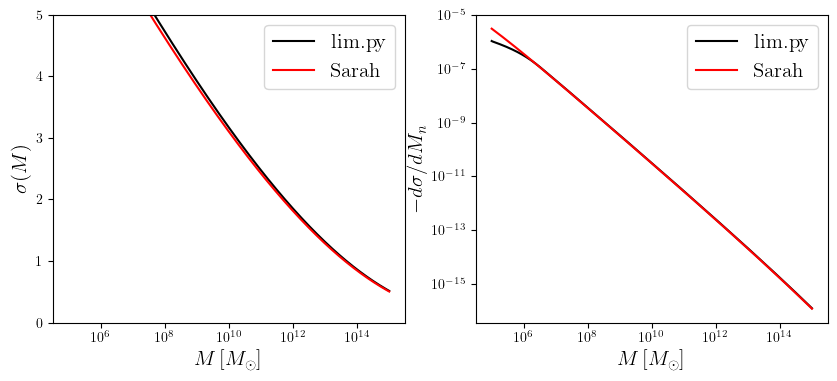

In [26]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.semilogx(use_M,use_lim.sigmaM,'k',label=r'$\rm lim.py$')
plt.semilogx(use_M,use_sigma,'r',label=r'$\rm Sarah$')
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$\sigma(M)$',fontsize=15)
plt.legend(fontsize=15)
plt.ylim(0,5)

plt.subplot(122)
plt.loglog(use_M,-use_lim.dsigmaM_dM,'k',label=r'$\rm lim.py$')
plt.loglog(use_M,-use_dsigmadM,'r',label=r'$\rm Sarah$')
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$-d\sigma/dM_{n}$',fontsize=15)
plt.legend(fontsize=15)

In [27]:
use_k3 = np.zeros(len(use_M))
use_k3_cutoff = np.zeros(len(use_M))
use_der_k3 = np.zeros(len(use_M))
use_der_k3_cutoff = np.zeros(len(use_M))
for i in range(len(use_M)):

    dn3_i = three_point_interpolations(use_M[i],use_M[i],ddd_flattened)
    dn3_cutoff_i = three_point_interpolations(use_M[i],use_M[i],ddd_flattened_cutoff)

    der_dn3_i = three_point_interpolations(use_M[i],use_M[i],der_dn3_flattened)
    der_dn3_cutoff_i = three_point_interpolations(use_M[i],use_M[i],der_dn3_flattened_cutoff)

    use_k3[i] = dn3_i / use_sigma[i]**3
    use_k3_cutoff[i] = dn3_cutoff_i / use_sigma[i]**3

    use_der_k3[i] = (der_dn3_i - 3.*dn3_i * use_dsigmadM[i] / use_sigma[i])/use_sigma[i]**3
    use_der_k3_cutoff[i] = (der_dn3_cutoff_i - 3.*dn3_cutoff_i * use_dsigmadM[i] / use_sigma[i])/use_sigma[i]**3

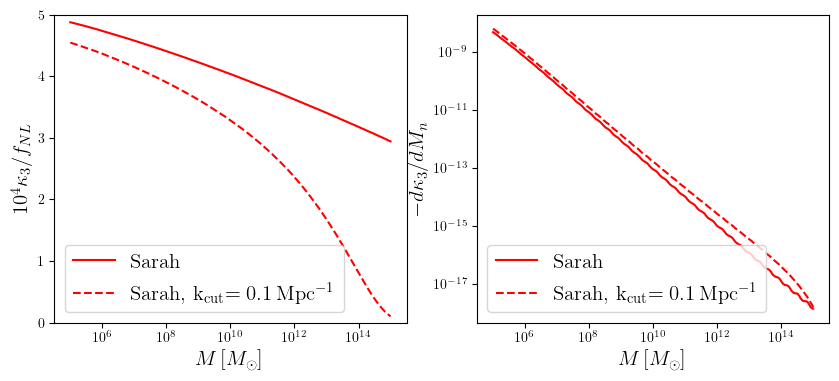

In [28]:
plt.figure(figsize=(10,4))
plt.subplot(121)
# plt.semilogx(use_M,1e4*k3_J/cosmo_params_fNL['F_NL'],'k',label=r'$\rm lim.py$')
# plt.semilogx(use_M,1e4*k3_J_cutoff/cosmo_params_fNL['F_NL'],'k--',label=r'$\rm lim.py,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.semilogx(use_M,1e4*use_k3/cosmo_params_fNL['F_NL'],'r',label=r'$\rm Sarah$')
plt.semilogx(use_M,1e4*use_k3_cutoff/cosmo_params_fNL['F_NL'],'r--',label=r'$\rm Sarah,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$10^4\kappa_3/f_{NL}$',fontsize=15)
plt.legend(fontsize=15)
plt.ylim(0,5)

plt.subplot(122)
# plt.loglog(use_M,-der_k3_J,'k',label=r'$\rm lim.py$')
# plt.loglog(use_M,-der_k3_J_cutoff,'k--',label=r'$\rm lim.py,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.loglog(use_M,-use_der_k3,'r',label=r'$\rm Sarah$')
plt.loglog(use_M,-use_der_k3_cutoff,'r--',label=r'$\rm Sarah,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$-d\kappa_3/dM_{n}$',fontsize=15)
plt.legend(fontsize=15)

In [15]:
LOG_Z_ARR = [0.69897, 0.73291816, 0.76686631, 0.80081447, 0.83476262,
                           0.86871078, 0.90265893, 0.93660709, 0.97055524, 1.0045034,
                           1.03845155, 1.07239971, 1.10634786, 1.14029602, 1.17424417,
                           1.20819233, 1.24214048, 1.27608864, 1.31003679, 1.34398495,
                           1.3779331 , 1.41188126, 1.44582941, 1.47977756, 1.51372572,
                           1.54767387, 1.58162203, 1.61557018, 1.64951834, 1.68346649,
                           1.71741465, 1.7513628 , 1.78531096, 1.81925911, 1.85320727,
                           1.88715542, 1.92110358, 1.95505173, 1.98899989, 2.02294804,
                           2.0568962 , 2.09084435, 2.12479251, 2.15874066, 2.19268882,
                           2.22663697, 2.26058512, 2.29453328, 2.32848143, 2.36242959,
                           2.39637774, 2.4303259 , 2.46427405, 2.49822221, 2.53217036,
                           2.56611852, 2.60006667, 2.63401483, 2.66796298, 2.70191114,
                           2.73585929, 2.76980745, 2.8037556 , 2.83770376, 2.87165191,
                           2.90560007, 2.93954822, 2.97349638, 3.00744453, 3.04139269]

LOG_SIGF = list(
    np.log10(np.array([CLASS_OUTPUT.scale_independent_growth_factor(pow(10.,log_z)) for log_z in LOG_Z_ARR])))


def dicke(z,use_LOG_SIGF):

    LOG_SIGF_use = use_LOG_SIGF
    if z == 0.:
        return 1. 
    log_z_arr = np.array(LOG_Z_ARR, dtype=float)
    log_SIGF_arr = np.array(LOG_SIGF_use, dtype=float)

    _CLASS_growth_spline = CubicSpline(
        log_z_arr,
        log_SIGF_arr,
        bc_type='natural'
    )

    # --------------------------------------------------
    # Evaluate spline
    # --------------------------------------------------
    if _CLASS_growth_spline is None:
        raise RuntimeError(
            "CLASS_GROWTH_FACTOR called before spline initialization (flag=1)"
        )

    log10_z = np.log10(z)

    if log10_z > LOG_Z_ARR[len(LOG_Z_ARR) - 1]:
        raise ValueError(f"Called CLASS_GROWTH_FACTOR with z={z}")

    ans = _CLASS_growth_spline(log10_z)
    
    return 10.0**ans
   

Non Gaussian Correction

In [30]:
def dNdM_J(z, M, NON_GAUSS_FCOLL, use_ddd_flattened,use_der_dn3_flattened,use_LOG_SIGF,use_SIGMA_MZ):

    growthf = dicke(z,use_LOG_SIGF)
    sigma = sigma_linear_2D_interpolation(M,z,use_SIGMA_MZ)/growthf
    dsigmadm = sigma_numerical_derivative(M,z,use_SIGMA_MZ)/growthf**2

    nu_c = 1.42 / growthf / sigma
    nu_c_prime = - 1.42 / growthf / sigma**2 * dsigmadm

    dfcoll_dMmin_EPS = (
        nu_c_prime
        * np.exp(-nu_c**2 / (2.0))
        / np.sqrt(np.pi*2)
    )

    if NON_GAUSS_FCOLL:

        delta_n3 = three_point_interpolations(M, M, use_ddd_flattened) 
        
        ddelta_n3_dMmin = three_point_interpolations(M, M,use_der_dn3_flattened)

        k3 = delta_n3 / sigma**3 

        k3_prime = (ddelta_n3_dMmin - delta_n3 * 3. / sigma * dsigmadm)/ sigma**3 

        H3 = -(3*nu_c - nu_c**3)

        H2 = (nu_c**2 - 1)

        dfcoll_dMmin_NG = k3*H3/6. - H2/6. * k3_prime / nu_c_prime
    else:   
        dfcoll_dMmin_NG = 0. 

    dfcoll = -(1. + dfcoll_dMmin_NG)*dfcoll_dMmin_EPS

    return dfcoll

In [31]:
corr = np.zeros(len(use_M))
corr_cutoff = np.zeros(len(use_M))
corr1 = np.zeros(len(use_M))
corr_cutoff1 = np.zeros(len(use_M))
z = 0.
z1 = 6.
for i in range(len(use_M)):

    gauss = dNdM_J(z, use_M[i], False, '','',LOG_SIGF,SIGMA_MZ)
    gauss1 = dNdM_J(z1, use_M[i], False, '','',LOG_SIGF,SIGMA_MZ)

    non_gauss = dNdM_J(z, use_M[i], True, ddd_flattened,der_dn3_flattened,LOG_SIGF,SIGMA_MZ)

    non_gauss_cutoff = dNdM_J(z,use_M[i], True, ddd_flattened_cutoff,der_dn3_flattened_cutoff,LOG_SIGF,SIGMA_MZ)

    corr[i] = non_gauss / gauss
    corr_cutoff[i] = non_gauss_cutoff / gauss

    non_gauss1 = dNdM_J(z1, use_M[i], True, ddd_flattened,der_dn3_flattened,LOG_SIGF,SIGMA_MZ)

    non_gauss_cutoff1 = dNdM_J(z1,use_M[i], True, ddd_flattened_cutoff,der_dn3_flattened_cutoff,LOG_SIGF,SIGMA_MZ)

    corr1[i] = non_gauss1 / gauss1
    corr_cutoff1[i] = non_gauss_cutoff1 / gauss1

(100000.0, 1000000000000.0)

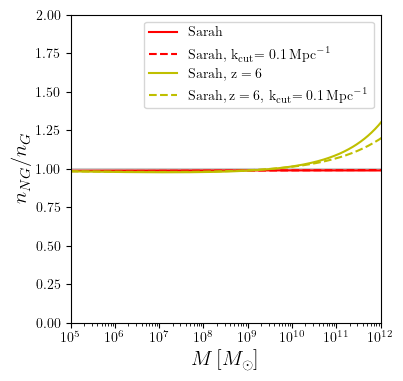

In [32]:
plt.figure(figsize=(4,4))
plt.axhline(1,color='k',alpha=0.2)
# plt.semilogx(use_M,1 + corr_J,'k',label=r'$\rm lim.py$')
# plt.semilogx(use_M,1 + corr_J_cutoff,'k--',label=r'$\rm lim.py,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.semilogx(use_M,corr,'r',label=r'$\rm Sarah$')
plt.semilogx(use_M,corr_cutoff,'r--',label=r'$\rm Sarah,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$')
plt.semilogx(use_M,corr1,'y',label=r'$\rm Sarah,\,z=%g$'%z1)
plt.semilogx(use_M,corr_cutoff1,'y--',label=r'$\rm Sarah,z=%g,\,k_{\rm cut}{=0.1\,Mpc}^{-1}$'%z1)
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$n_{NG}/n_G$',fontsize=15)
plt.legend(fontsize=10)
plt.ylim(0,2)
plt.xlim(1e5,1e12)

### Comparison with D'Alosio

In [16]:
cosmo_params_mfNL ={"hlittle": 0.6727, # hubble parameter
                "OMb": 0.02236/0.6727**2, # baryon density
                "OMm": 0.1202/0.6727**2, # matter (CDM+baryon) density
                "A_s": 2.101e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":-100., # to test matching with old case
                "ANALYTICAL_DER_TPF":True}

In [17]:
ddd_m, der_dn3_m, der_dmn2_m, der_dnm2_m = tpf(log10_M_array,cosmo_params_mfNL,kcutoff=1e-3,T_ZETA_TRANSFER=T_ZETA_TRANSFER,CLASS=CLASS_OUTPUT) 

Computing three point functions to estimate the Fcoll NG corrections...


In [18]:
ddd_flattened_m = list(ddd_m.flatten())
der_dn3_flattened_m = list(der_dn3_m.flatten())
der_dnm2_flattened_m = list(der_dnm2_m.flatten())
der_dmn2_flattened_m = list(der_dmn2_m.flatten())



/tmp/ipykernel_1490675/3311276189.py:64: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,4)


Text(0, 0.5, '$d\\langle \\delta_i\\delta_j\\delta_k\\rangle_c/dM_n/ (10^{-4}f_{\\rm NL})$')

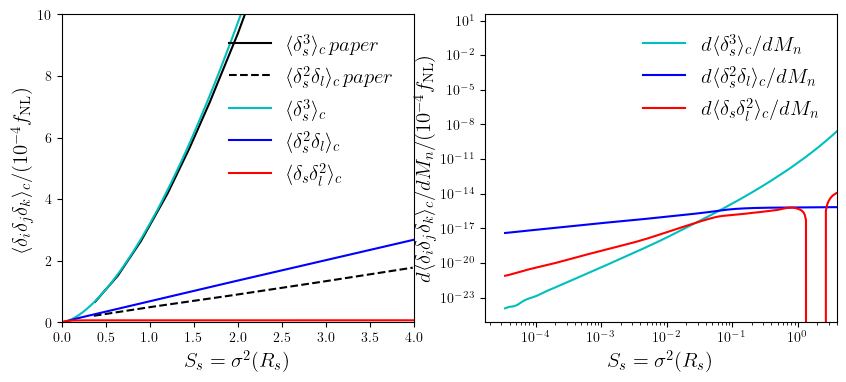

In [21]:
Ml = 1e16 

M_array = 10**log10_M_array[:-5]
x = np.zeros(len(M_array))
dn3 = np.zeros(len(M_array))
dnm2 = np.zeros(len(M_array))
dmn2 = np.zeros(len(M_array))

use_der_dn3 = np.zeros(len(M_array))
use_der_dnm2 = np.zeros(len(M_array))
use_der_dmn2 = np.zeros(len(M_array))

for i in range(len(M_array)):
    x[i] = sigma_Mz(M_array[i],0.,cosmo_params_fNL,CLASS_OUTPUT)**2

    dn3[i] = three_point_interpolations(M_array[i], M_array[i], ddd_flattened) / cosmo_params_fNL['F_NL'] / 1e-4 
    dnm2[i] = three_point_interpolations(M_array[i], Ml, ddd_flattened) / cosmo_params_fNL['F_NL'] / 1e-4
    dmn2[i] = three_point_interpolations(Ml, M_array[i], ddd_flattened) / cosmo_params_fNL['F_NL'] / 1e-4

    use_der_dn3[i] = three_point_interpolations(M_array[i], M_array[i], der_dn3_flattened) / cosmo_params_fNL['F_NL'] / 1e-4 
    use_der_dnm2[i] = three_point_interpolations(M_array[i], Ml, der_dnm2_flattened) / cosmo_params_fNL['F_NL'] / 1e-4
    use_der_dmn2[i] = three_point_interpolations(M_array[i], Ml, der_dmn2_flattened) / cosmo_params_fNL['F_NL'] / 1e-4


d3_paper = np.asarray((
[0.3773577916706111, 0.66854892147622],
[0.6343102674804816, 1.51441118487392],
[0.8965679031653985, 2.63632285334464],
[1.2001267640994193, 4.18814591041730],
[1.4472179807466738, 5.65044388013385],
[1.678949339633125, 7.151363742998148],
[1.9983290186894735, 9.38366307090148],
[2.0730622173016533, 9.96745290590236],))

dd_paper = np.asarray((
[0.3616810236612601, 0.2127908268888081],
[1.023406085499916, 0.5038872951916176],
[1.915948816937001, 0.8705483370443563],
[2.9726510571220444, 1.3260430257109146],
[3.9831955253919205, 1.7754135267172142],
))

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(d3_paper[:,0],d3_paper[:,1],color='k',label=r'$\langle\delta_s^3\rangle_c\,paper$')
plt.plot(dd_paper[:,0],dd_paper[:,1],'k--',label=r'$\langle\delta_s^2\delta_l\rangle_c\,paper$')
plt.plot(x,dn3,color='c',label=r'$\langle\delta_s^3\rangle_c$')
plt.plot(x,dmn2,'b',label=r'$\langle\delta_s^2\delta_l\rangle_c$')
plt.plot(x,dnm2,'r',label=r'$\langle\delta_s\delta_l^2\rangle_c$')


plt.legend(fontsize=15,frameon=False)
plt.xlim(0,4)
plt.xlabel(r'$S_s=\sigma^2(R_s)$',fontsize=15)
plt.ylim(0,10)
plt.ylabel(r'$\langle \delta_i\delta_j\delta_k\rangle_c / (10^{-4}f_{\rm NL})$',fontsize=15)

plt.subplot(122)
plt.loglog(x,-use_der_dn3/ cosmo_params_fNL['F_NL'] / 1e-4 ,color='c',label=r'$d\langle\delta_s^3\rangle_c/dM_n$')
plt.loglog(x,-use_der_dmn2/ cosmo_params_fNL['F_NL'] / 1e-4 ,'b',label=r'$d\langle\delta_s^2\delta_l\rangle_c/dM_n$')
plt.loglog(x,-use_der_dnm2/ cosmo_params_fNL['F_NL'] / 1e-4 ,'r',label=r'$d\langle\delta_s\delta_l^2\rangle_c/dM_n$')

plt.legend(fontsize=15,frameon=False)
plt.xlim(0,4)
plt.xlabel(r'$S_s=\sigma^2(R_s)$',fontsize=15)
plt.ylabel(r'$d\langle \delta_i\delta_j\delta_k\rangle_c/dM_n/ (10^{-4}f_{\rm NL})$',fontsize=15)


In [82]:
def dNdM_conditional(growthf, M1, M2, delta1, delta2, sigma2, z, NON_GAUSS_FCOLL,NG_MODEL_APPROX,ANALYTICAL_DER_TPF,use_ddd_flattened,use_der_dn3_flattened, use_der_dnm2_flattened, use_der_dmn2_flattened,cosmo_params,corrected = False):
    """
    Conditional mass function derivative (Python translation of C code)
    """

    if z is False:
        sigma1 = sigma_linear_2D_interpolation(np.exp(M1),0.,SIGMA_MZ);
        dsigmadm = sigma_numerical_derivative(np.exp(M1),0.,SIGMA_MZ);

    else:
        sigma1 = sigma_linear_2D_interpolation(np.exp(M1),z,SIGMA_MZ)/dicke(z,LOG_SIGF);
        dsigmadm = sigma_numerical_derivative(np.exp(M1),z,SIGMA_MZ)/dicke(z,LOG_SIGF)/dicke(z,LOG_SIGF) ;

    # --------------------------------------------------
    # Convert log-masses to masses
    # --------------------------------------------------
    M1 = np.exp(M1)
    M2 = np.exp(M2)

    sigma1 = sigma1**2
    sigma2 = sigma2**2

    den_MIN = 1e-6

    # --------------------------------------------------
    # EPS Gaussian part
    # --------------------------------------------------
    DD = (delta1 - delta2) / growthf
    SS = sigma1 - sigma2

    if SS < den_MIN or sigma2**2 < den_MIN :
       return 0.0
    
    dfcoll_dSmin_EPS = (
        DD
        * np.exp(-DD**2 / (2.0 * SS))
        / SS**1.5
        / np.sqrt(np.pi*2)
    )


    # --------------------------------------------------
    # Non-Gaussian corrections
    # --------------------------------------------------
    dfcoll_dMmin_NG = 0.0
    
    if NON_GAUSS_FCOLL and cosmo_params['F_NL'] != 0.0:

        # if (
        #     (delta1 / growthf <= delta2 / growthf and NG_MODEL_APPROX)
        #     or (delta1 / growthf)**2 < sigma2 and NG_MODEL_APPROX
        #     or abs(DD) < den_MIN
        # ):
        #     dfcoll_dMmin_NG = 0.0

        # else:

            if DD < den_MIN:
               dfcoll_dMmin_NG = 0.0
            else:
                # Three-point functions
                delta_n3 = three_point_interpolations(M1, M1, use_ddd_flattened)
                delta_m3 = three_point_interpolations(M2, M2, use_ddd_flattened)
                delta_m2delta_n = three_point_interpolations(M1, M2, use_ddd_flattened)
                delta_mdelta_n2 = three_point_interpolations(M2, M1, use_ddd_flattened)


                if ANALYTICAL_DER_TPF:
                    ddelta_n3_dMmin = three_point_interpolations(M1, M1,use_der_dn3_flattened)
                    ddelta_m2delta_n_dMin =  three_point_interpolations(M1, M2,use_der_dnm2_flattened)
                    ddelta_mdelta_n2_dMin =  three_point_interpolations(M2, M1,use_der_dmn2_flattened)
                
                # A, B, C coefficients
                A_v = (
                    delta_n3
                    - delta_m3
                    + 3.0 * delta_m2delta_n
                    - 3.0 * delta_mdelta_n2
                )
                dA_dMmin = (
                    ddelta_n3_dMmin
                    + 3.0 * ddelta_m2delta_n_dMin
                    - 3.0 * ddelta_mdelta_n2_dMin
                )

                B_v =  (delta_m3 + delta_mdelta_n2 - 2.0 * delta_m2delta_n)
                dB_dMmin = (ddelta_mdelta_n2_dMin - 2.0 * ddelta_m2delta_n_dMin)

                C_v = delta_m2delta_n - delta_m3
                dC_dMmin = ddelta_m2delta_n_dMin

                # Compact variables
                x = SS / (DD * DD)

                alpha = -(1.0 / (DD * DD)) * (
                    1.0 / (1.0 - x) + 2.5 / x - 0.5 / (x * x)
                )

                beta = (1.0 / (2.0 * DD * DD)) * (1.0 / (x * x) - 3.0 / x)
                gamma = (1.0 / (2.0 * DD * DD)) * (1.0 / (x * x) - 1.0 / x)
                chi = (1.0 / (3.0 * DD)) * (1.0 / x - 1.0)

                if NG_MODEL_APPROX:
                    psi = (delta2 / growthf) / sigma2
                    w = 0.0
                else:
                    y = delta1 * DD / (growthf * sigma2)

                    psi = (
                        (delta1 / growthf - DD) / sigma2
                        - (2.0 * DD / sigma2) / (np.exp(2.0 * y) - 1.0)
                    )

                    w = (
                        SS / (sigma2 * DD) / sigma2
                        * (
                            (delta2 / growthf)**2
                            - sigma2
                            - (4.0 * delta1 * DD / growthf)
                            / (np.exp(2.0 * y) - 1.0)
                        )
                    )

                
                dfcoll_dMmin_NG = (
                    (dA_dMmin + alpha * A_v * dsigmadm) * chi
                    + (dB_dMmin + beta * B_v * dsigmadm) * psi
                    + (dC_dMmin + gamma * C_v * dsigmadm) * w
                )


    dfcoll = -(dsigmadm + dfcoll_dMmin_NG)* dfcoll_dSmin_EPS

    if dfcoll < 0.:
        dfcoll = 0. 
    
    return dfcoll

/tmp/ipykernel_1390630/1739765877.py:39: RuntimeWarning: invalid value encountered in scalar power
  / SS**1.5
/tmp/ipykernel_1390630/1739765877.py:114: RuntimeWarning: overflow encountered in exp
  - (2.0 * DD / sigma2) / (np.exp(2.0 * y) - 1.0)
/tmp/ipykernel_1390630/1739765877.py:123: RuntimeWarning: overflow encountered in exp
  / (np.exp(2.0 * y) - 1.0)
/tmp/ipykernel_1390630/1739765877.py:38: RuntimeWarning: overflow encountered in exp
  * np.exp(-DD**2 / (2.0 * SS))
/tmp/ipykernel_1390630/183997007.py:23: RuntimeWarning: invalid value encountered in divide
  ax[0].semilogx(10**use_M_array, ng / gauss ,label=r'$z=%g$'%zz,color=colors[zfn_arr.index(zz)])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1000000.0, 1e+16)

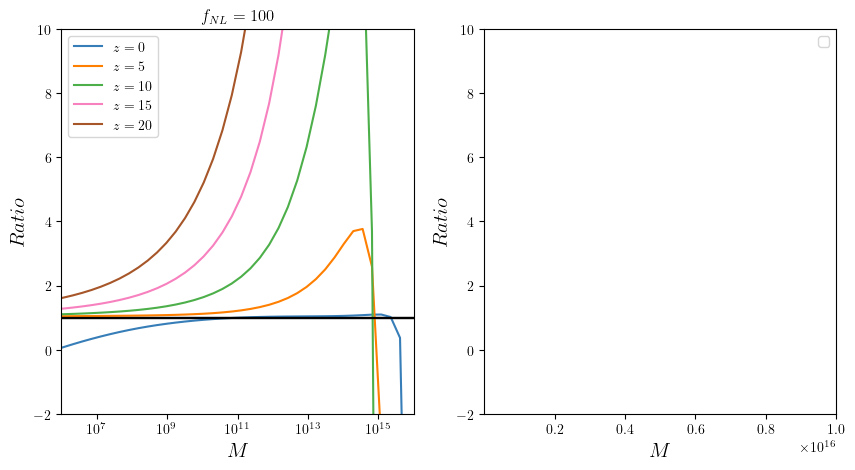

In [23]:
zfn_arr = [0.,5.,10.,15.,20.]
delta_c = 1.68 

Ml = np.log10(1e16 ) #log10_M_array[257] 
sigmal = sigma_Mz(10**Ml,z=0.,cosmo_params=cosmo_params_fNL,CLASS=CLASS_OUTPUT)
use_M_array = np.log10(np.logspace(5.,18.)) #log10_M_array #np.logspace(5,15) #/ h

fig, ax = plt.subplots(1,2,figsize=(10,5))

for zz in zfn_arr:
    gauss = np.zeros(len(use_M_array))
    ng = np.zeros(len(use_M_array))

    delta2 = sigmal * dicke(zz,LOG_SIGF)

    for i in range(len(use_M_array)):

        gauss[i] = dNdM_conditional(dicke(zz,LOG_SIGF), np.log(10**use_M_array[i]), np.log(10**Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zz, NON_GAUSS_FCOLL=False,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened='',use_der_dn3_flattened='', use_der_dnm2_flattened='', use_der_dmn2_flattened='', cosmo_params=cosmo_params_fNL)

        ng[i] = dNdM_conditional(dicke(zz,LOG_SIGF), np.log(10**use_M_array[i]), np.log(10**Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zz, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened,use_der_dn3_flattened=der_dn3_flattened, use_der_dnm2_flattened=der_dnm2_flattened, use_der_dmn2_flattened=der_dmn2_flattened,cosmo_params=cosmo_params_fNL)
        
    ax[0].semilogx(M_array,np.ones(len(M_array)),color='k')
    ax[0].semilogx(10**use_M_array, ng / gauss ,label=r'$z=%g$'%zz,color=colors[zfn_arr.index(zz)])


ax[0].set_ylabel(r'$Ratio$',fontsize=15)
ax[0].set_xlabel(r'$M$',fontsize=15)
ax[0].legend()
ax[0].set_title(r'$f_{NL}=%g$'%(cosmo_params_fNL['F_NL']))
ax[1].set_ylabel(r'$Ratio$',fontsize=15)
ax[1].set_xlabel(r'$M$',fontsize=15)
ax[1].legend()

ax[0].set_ylim(-2,10)
ax[1].set_ylim(-2,10)

ax[0].set_xlim(1e6,1e16)
ax[1].set_xlim(1e6,1e16)

/tmp/ipykernel_1390630/1739765877.py:39: RuntimeWarning: invalid value encountered in scalar power
  / SS**1.5


Text(0.5, 0, '$M$')

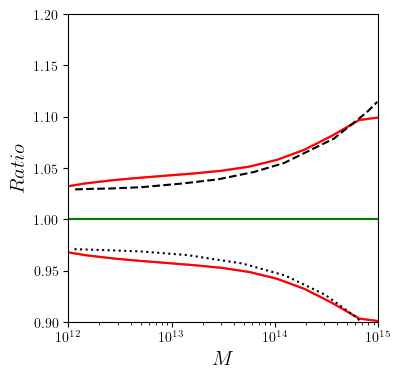

In [24]:
delta_c = 1.686
zfn = 0.

Ml = np.log10(1e16) 
sigmal = sigma_Mz(10**Ml,z=0.,cosmo_params=cosmo_params_fNL,CLASS=CLASS_OUTPUT)
delta2 = sigmal*dicke(zfn,LOG_SIGF)
use_M_array = np.log10(np.logspace(5.,18.)) 

gauss = np.zeros(len(use_M_array))
ng = np.zeros(len(use_M_array))
mng = np.zeros(len(use_M_array))
ng_corr = np.zeros(len(use_M_array))
mng_corr = np.zeros(len(use_M_array))
corr_J_second = np.zeros(len(use_M_array))

for i in range(len(use_M_array)):

    gauss[i] = dNdM_conditional(dicke(zfn,LOG_SIGF), np.log(10**use_M_array[i]), np.log(10**Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfn, NON_GAUSS_FCOLL=False,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened='',use_der_dn3_flattened='', use_der_dnm2_flattened='', use_der_dmn2_flattened='', cosmo_params=cosmo_params_fNL)

    ng[i] = dNdM_conditional(dicke(zfn,LOG_SIGF), np.log(10**use_M_array[i]), np.log(10**Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfn, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened,use_der_dn3_flattened=der_dn3_flattened, use_der_dnm2_flattened=der_dnm2_flattened, use_der_dmn2_flattened=der_dmn2_flattened,cosmo_params=cosmo_params_fNL)

    mng[i] = dNdM_conditional(dicke(zfn,LOG_SIGF), np.log(10**use_M_array[i]), np.log(10**Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfn, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL)
    
    ng_corr[i] = dNdM_conditional(dicke(zfn,LOG_SIGF), np.log(10**use_M_array[i]), np.log(10**Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfn, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened,use_der_dn3_flattened=der_dn3_flattened, use_der_dnm2_flattened=der_dnm2_flattened, use_der_dmn2_flattened=der_dmn2_flattened,cosmo_params=cosmo_params_fNL,corrected=False)

    mng_corr[i] = dNdM_conditional(dicke(zfn,LOG_SIGF), np.log(10**use_M_array[i]), np.log(10**Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfn, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL,corrected=False)
    
    #corr_J_second[i] = dNdM_J(zfn, 10**use_M_array[i], True, ddd_flattened,der_dn3_flattened,LOG_SIGF,SIGMA_MZ)
    
dn = [
[1163324850048.2913, 1.02913816689466],
[1721078899873.988, 1.029685362517099],
[2482702844599.4077, 1.02995896032831],
[5166284215610.403, 1.031326949384404],
[12750315567929.076, 1.03488372093023],
[28263640072772.617, 1.03898768809849],
[62655023319122.555, 1.04610123119014],
[122412360531015.33, 1.05485636114911],
[372256041006493.94, 1.07865937072503],
[770046510624236.8, 1.104103967168262],
[979130695644417.2, 1.114500683994527],
]

mdn = [
[1147662883302.1863, 0.97086183310533],
[2213762702187.802, 0.970041039671682],
[5096377634843.602, 0.968673050615594],
[14270038176142.305, 0.96511627906976],
[48596476163836.22, 0.956908344733241],
[126121813268269.6, 0.945143638850888],
[305316583240491.9, 0.926538987688097],
[585043999219359.9, 0.906019151846784],
[933431625199504.2, 0.887961696306429],
]

dn = np.asanyarray(dn).T
mdn = np.asanyarray(mdn).T

fig, ax = plt.subplots(1,1,figsize=(4,4))

use_M_array = 10**use_M_array
ax.semilogx(M_array,np.ones(len(M_array)))
ax.semilogx(use_M_array, ng / gauss , 'r')
ax.semilogx(use_M_array, mng / gauss , 'r')
ax.semilogx(use_M_array, ng_corr / gauss , 'r',alpha=0.6)
ax.semilogx(use_M_array, mng_corr / gauss , 'r',alpha=0.6)
ax.semilogx(use_M_array, 1+corr_J_second, 'g')

ax.semilogx(dn[0], dn[1] , 'k--', label=r'$\rm 100\,paper$')
ax.semilogx(mdn[0], mdn[1] , 'k:', label=r'$\rm -100\,paper$')

ax.set_ylim(0.9,1.2)
ax.set_xlim(1e12,1e15)

ax.set_ylabel(r'$Ratio$',fontsize=15)
ax.set_xlabel(r'$M$',fontsize=15)

In [40]:
from scipy.special import erfc

In [41]:
def fcoll(growthf, M1, M2, delta1, delta2, sigma2, z, NON_GAUSS_FCOLL,NG_MODEL_APPROX, ddd_flattened,cosmo_params=cosmo_params_fNL,LOG_SIGF=LOG_SIGF,SIGMA_MZ=SIGMA_MZ):
    """
    Conditional mass function derivative (Python translation of C code)
    """

    den_MIN = 1e-5

    sigma1 = sigma_linear_2D_interpolation(np.exp(M1),z,SIGMA_MZ)/dicke(z,LOG_SIGF);

    # --------------------------------------------------
    # Convert log-masses to masses
    # --------------------------------------------------
    M1 = np.exp(M1)
    M2 = np.exp(M2)

    sigma1 = sigma1**2
    sigma2 = sigma2**2

    # --------------------------------------------------
    # EPS Gaussian part
    # --------------------------------------------------
    DD = (delta1 - delta2) / growthf
    SS = sigma1 - sigma2

    if SS < den_MIN:
        return 0.0

    fcoll_EPS = erfc(
        DD / np.sqrt(2.*SS)
    )

    # --------------------------------------------------
    # Non-Gaussian corrections
    # --------------------------------------------------
    fcoll_NG = 0.0

    if NON_GAUSS_FCOLL and cosmo_params_fNL['F_NL'] != 0.0:

        # if (
        #     (delta1 / growthf <= delta2 / growthf and NG_MODEL_APPROX)
        #     or (delta1 / growthf)**2 < sigma2 and NG_MODEL_APPROX
        #     or abs(DD) < den_MIN
        # ):
        #     fcoll_NG = 0.0

        # else:

            # Three-point functions
            delta_n3 = three_point_interpolations(M1, M1, ddd_flattened)
            delta_m3 = three_point_interpolations(M2, M2, ddd_flattened)
            delta_m2delta_n = three_point_interpolations(M1, M2, ddd_flattened)
            delta_mdelta_n2 = three_point_interpolations(M2, M1, ddd_flattened)

            # A, B, C coefficients
            A_v = (
                delta_n3
                - delta_m3
                + 3.0 * delta_m2delta_n
                - 3.0 * delta_mdelta_n2
            )

            B_v =  (delta_m3 + delta_mdelta_n2 - 2.0 * delta_m2delta_n)

            C_v = delta_m2delta_n - delta_m3

            dfcoll_dSmin_EPS = (
                DD
                * np.exp(-DD**2 / (2.0 * SS))
                / SS**1.5
                / np.sqrt(np.pi*2)
            )

            if NG_MODEL_APPROX:
                coth = 1. 
                T3 = 0. 
            else:
                coth = 1. / np.tanh(delta1 / growthf * DD / sigma2)
                T3 = C_v * SS / (sigma2**2 * DD) * ((delta2/growthf)**2 - sigma2 - 2*delta1/growthf * DD * (coth -1.))

            T1 = A_v / 3. * (DD/SS - 1./DD)

            T2 = B_v / sigma2 * (delta1 / growthf - DD * coth)
            fcoll_NG = dfcoll_dSmin_EPS * (T1 + T2 + T3)


    fcoll = (fcoll_EPS + fcoll_NG) 
    
    return fcoll

In [24]:
f2_paper = np.asarray((
[1120032872527.642, 1.005359924026591],
[2645843196615.7124, 1.007082832119869],
[8142714930301.295, 1.0121215574548912],
[39065633539842.33, 1.0254304104674479],
[158115468412466.25, 1.047777566740530],
[616231067650271.2, 1.0915205233723757],
[997641160707717.5, 1.1162549329956744],
))

mf2_paper = np.asarray((
[1254473635542.5264, 0.995081987970877],
[4797617732443.058, 0.9906751081565899],
[50415502770415.62, 0.9719552601034087],
[253572740370093.1, 0.9420584573177171],
[716777914648753.4, 0.9026451408673638],
[992940161366685.1, 0.8849787907565692],
))


mmpaper = np.asarray((
[0.05459057071960305, 1.00212505586979],
[0.6104218362282884, 1.009468119538245],
[1.126550868486353, 1.0160559776829061],
[1.6823821339950387, 1.021659910916573],
[2.3101736972704727, 1.027281722485088],
[2.8808933002481405, 1.031150224249803],
[2.980148883374693, 1.0326655672518226],
))

mmmpaper = np.asarray((
[0.11166253101736978, 0.99741873834440],
[0.6302729528535983, 0.990839511120015],
[1.1662531017369733, 0.985258388175639],
[1.7468982630272962, 0.979439914923785],
[2.2282878411910683, 0.975335912334509],
[2.799007444168736, 0.9710056563352496],
[2.9813895781637734, 0.969808732641832],
))

delta_c = 1.68
zfc = 0.

Ml = 1e16 #/ h
sigmal = sigma_Mz(Ml,z=0.,cosmo_params=cosmo_params_fNL,CLASS=CLASS_OUTPUT)
delta2 = sigmal
use_M_array = np.logspace(5,15)#/ h

fAdam = np.zeros(len(use_M_array))
fDAl = np.zeros(len(use_M_array))
fgauss = np.zeros(len(use_M_array))

for i in range(len(use_M_array)):

    fgauss[i] = fcoll(dicke(zfc,LOG_SIGF), np.log(use_M_array[i]), M2=np.log(Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfc, NON_GAUSS_FCOLL=False,NG_MODEL_APPROX=True,ddd_flattened=ddd_flattened,cosmo_params=cosmo_params_fNL,LOG_SIGF=LOG_SIGF,SIGMA_MZ=SIGMA_MZ)

    fAdam[i] = fcoll(dicke(zfc,LOG_SIGF), np.log(use_M_array[i]), M2=np.log(Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfc, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=True,ddd_flattened=ddd_flattened,cosmo_params=cosmo_params_fNL,LOG_SIGF=LOG_SIGF,SIGMA_MZ=SIGMA_MZ)


    fDAl[i] = fcoll(dicke(zfc,LOG_SIGF), np.log(use_M_array[i]), M2=np.log(Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfc, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ddd_flattened=ddd_flattened,cosmo_params=cosmo_params_fNL,LOG_SIGF=LOG_SIGF,SIGMA_MZ=SIGMA_MZ)
    
        

plt.figure(figsize=(10,4.3))
plt.subplot(121)
plt.semilogx(f2_paper[:,0],f2_paper[:,1],'k--',label=r'$f_{\rm NL}=%g\,paper$'%cosmo_params_fNL['F_NL'])
plt.semilogx(mf2_paper[:,0],mf2_paper[:,1],'k:',label=r'$f_{\rm NL}=%g\,paper$'%cosmo_params_mfNL['F_NL'])
plt.semilogx(use_M_array,fDAl /fgauss,'c--',label=r'$f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'])
plt.semilogx(use_M_array,fAdam /fgauss,'r-',label=r'$Adam,\,f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'])
plt.semilogx(use_M_array,fDAl /fgauss,'c--',label=r'$f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'])
plt.legend(fontsize=15,frameon=False,ncol=1)
plt.xlim(1e12,1e15)
plt.xlabel(r'$M_s$',fontsize=15)
#plt.ylim(0.9,1.1)
plt.ylabel(r'$f_{\rm coll}/f_{\rm coll}^{\rm gm}$',fontsize=15)

nu = np.linspace(0,3)

fmod = np.zeros(len(nu))
fmodDA = np.zeros(len(nu))
fmodgauss = np.zeros(len(nu))

Ml = 1e16 
Ms = 1e13 

sigmal = sigma_Mz(Ml,z=0.,cosmo_params=cosmo_params_fNL,CLASS=CLASS_OUTPUT)
delta2 = sigmal * nu

for i in range(len(use_M_array)):

    fmodgauss[i] = fcoll(dicke(zfc,LOG_SIGF), np.log(Ms), M2=np.log(Ml), delta1=delta_c, delta2=delta2[i], sigma2=sigmal, z=zfc, NON_GAUSS_FCOLL=False,ddd_flattened=ddd_flattened,NG_MODEL_APPROX=True,cosmo_params=cosmo_params_fNL)


    fmod[i] = fcoll(dicke(zfc,LOG_SIGF), np.log(Ms), M2=np.log(Ml), delta1=delta_c, delta2=delta2[i], sigma2=sigmal, z=zfc, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=True,cosmo_params=cosmo_params_fNL,ddd_flattened=ddd_flattened)

    fmodDA[i] = fcoll(dicke(zfc,LOG_SIGF), np.log(Ms), M2=np.log(Ml), delta1=delta_c, delta2=delta2[i], sigma2=sigmal, z=zfc, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,cosmo_params=cosmo_params_fNL,ddd_flattened=ddd_flattened)


plt.subplot(122)
plt.plot(mmpaper[:,0],mmpaper[:,1],'k--',label=r'$f_{\rm NL}=%g\,paper$'%cosmo_params_fNL['F_NL'])
plt.plot(mmmpaper[:,0],mmmpaper[:,1],'k:',label=r'$f_{\rm NL}=%g\,paper$'%cosmo_params_mfNL['F_NL'])
plt.plot(nu,fmod/fmodgauss,'r-',label=r'$Adam\,f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'])
plt.plot(nu,fmodDA/fmodgauss,'c--',label=r'$f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'])
plt.legend(fontsize=15,frameon=False,ncol=1)
plt.xlim(0,3)
plt.xlabel(r'$\nu_l$',fontsize=15)
plt.ylim(0.9,1.1)
plt.ylabel(r'$f_{\rm coll}/f_{\rm coll}^{\rm gm}$',fontsize=15)

NameError: name 'fcoll' is not defined

/tmp/ipykernel_1490675/949770806.py:52: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(use_M_array, ng_D / gauss , 'r',label=r'$300\,DAlosio$')
/tmp/ipykernel_1490675/949770806.py:53: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(use_M_array, ng_Dm / gauss , 'r--',label=r'$-300\,DAlosio$')
/tmp/ipykernel_1490675/949770806.py:54: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(use_M_array, ng_A / gauss , 'b-',label=r'$300\,Adam$')
/tmp/ipykernel_1490675/949770806.py:55: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(use_M_array, ng_Am / gauss , 'b--',label=r'$-300\,Adam$')
/tmp/ipykernel_1490675/949770806.py:57: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(use_M_array, ng_D_corr / gauss , 'r',alpha=0.6)
/tmp/ipykernel_1490675/949770806.py:58: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(use_M_array, ng_Dm_corr / gauss , 'r--',alpha=0.6)
/tmp/ipykernel_1490675/949770806.p

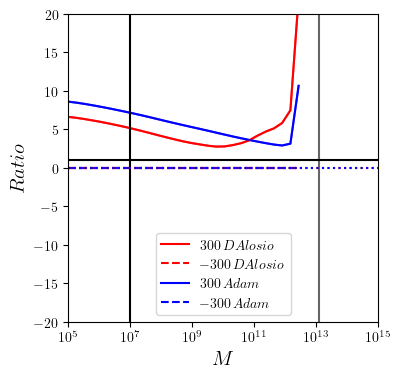

In [83]:
delta_c = 1.680000e+00 

corrM1 = 8

M1 = [np.log10(np.exp(1.612047e+01))]
Ml = [np.log10(np.exp(3.015559e+01 ))]
sigmal = [1.513865e+00] 
delta2 = [1.632965e+00]
growthf =[3.612738e-02]


for v in range(len(Ml)):

    use_M_array = np.log10(np.logspace(5.,18.)) 

    gauss = np.zeros(len(use_M_array))
    ng_D = np.zeros(len(use_M_array))
    ng_Dm = np.zeros(len(use_M_array))
    ng_A = np.zeros(len(use_M_array))
    ng_Am = np.zeros(len(use_M_array))

    ng_Dm_corr = np.zeros(len(use_M_array))
    ng_D_corr = np.zeros(len(use_M_array))
    ng_A_corr = np.zeros(len(use_M_array))
    ng_Am_corr = np.zeros(len(use_M_array))

    for i in range(len(use_M_array)):

        gauss[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=False,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened='',use_der_dn3_flattened='', use_der_dnm2_flattened='', use_der_dmn2_flattened='', cosmo_params=cosmo_params_fNL)

        ng_D[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened,use_der_dn3_flattened=der_dn3_flattened, use_der_dnm2_flattened=der_dnm2_flattened, use_der_dmn2_flattened=der_dmn2_flattened,cosmo_params=cosmo_params_fNL)
        
        ng_D_corr[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened,use_der_dn3_flattened=der_dn3_flattened, use_der_dnm2_flattened=der_dnm2_flattened, use_der_dmn2_flattened=der_dmn2_flattened,cosmo_params=cosmo_params_fNL,corrected=True)

        ng_Dm[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL)

        ng_Dm_corr[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL,corrected=True)

        ng_A[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened,use_der_dn3_flattened=der_dn3_flattened, use_der_dnm2_flattened=der_dnm2_flattened, use_der_dmn2_flattened=der_dmn2_flattened,cosmo_params=cosmo_params_fNL)

        ng_A_corr[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened,use_der_dn3_flattened=der_dn3_flattened, use_der_dnm2_flattened=der_dnm2_flattened, use_der_dmn2_flattened=der_dmn2_flattened,cosmo_params=cosmo_params_fNL,corrected=True)
        
        ng_Am[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL)

        ng_Am_corr[i] = dNdM_conditional(growthf[v], np.log(10**use_M_array[i]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL,corrected=True)
        

    fig, ax = plt.subplots(1,1,figsize=(4,4))

    use_M_array = 10**use_M_array
    ax.semilogx(M_array,np.ones(len(M_array)),'k')
    ax.semilogx(use_M_array, ng_D / gauss , 'r',label=r'$300\,DAlosio$')
    ax.semilogx(use_M_array, ng_Dm / gauss , 'r--',label=r'$-300\,DAlosio$')
    ax.semilogx(use_M_array, ng_A / gauss , 'b-',label=r'$300\,Adam$')
    ax.semilogx(use_M_array, ng_Am / gauss , 'b--',label=r'$-300\,Adam$')

    ax.semilogx(use_M_array, ng_D_corr / gauss , 'r',alpha=0.6)
    ax.semilogx(use_M_array, ng_Dm_corr / gauss , 'r--',alpha=0.6)
    ax.semilogx(use_M_array, ng_A_corr / gauss , 'b-',alpha=0.6)
    ax.semilogx(use_M_array, ng_Am_corr / gauss , 'b--',alpha=0.6)
    ax.axvline(10**M1[v],color='k')
    ax.axvline(10**Ml[v],color='k',alpha=0.6)

    gaus_val = dNdM_conditional(growthf[v], np.log(10**M1[v]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=False,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened='',use_der_dn3_flattened='', use_der_dnm2_flattened='', use_der_dmn2_flattened='',cosmo_params=cosmo_params_mfNL)
    D_val = dNdM_conditional(growthf[v], np.log(10**M1[v]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=False,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL)
    A_val = dNdM_conditional(growthf[v], np.log(10**M1[v]), np.log(10**Ml[v]), delta1=delta_c, delta2=delta2[v], sigma2=sigmal[v], z=False, NON_GAUSS_FCOLL=True,NG_MODEL_APPROX=True,ANALYTICAL_DER_TPF=True,use_ddd_flattened=ddd_flattened_m,use_der_dn3_flattened=der_dn3_flattened_m, use_der_dnm2_flattened=der_dnm2_flattened_m, use_der_dmn2_flattened=der_dmn2_flattened_m,cosmo_params=cosmo_params_mfNL)
    ax.axhline(D_val / gaus_val ,color='r',ls=':')
    ax.axhline(A_val / gaus_val,color='b',ls=':')

    ax.set_ylabel(r'$Ratio$',fontsize=15)
    ax.set_xlabel(r'$M$',fontsize=15)

    ax.legend()
    ax.set_xlim(1e5,1e15)
    ax.set_ylim(-20,20)


In [84]:
np.trapz(ng_Am,use_M_array)
# np.trapz(gauss,use_M_array)

0.0

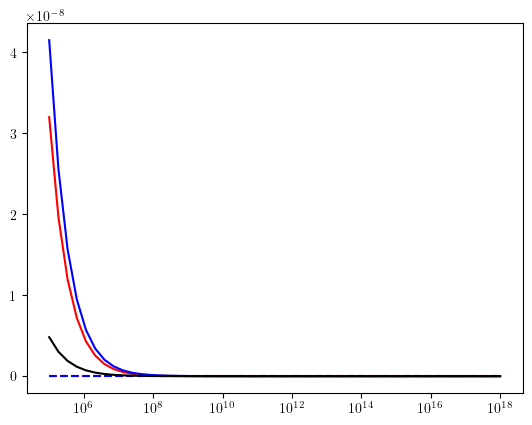

In [85]:
plt.semilogx(use_M_array, ng_D  , 'r',label=r'$300\,DAlosio$')
plt.semilogx(use_M_array, ng_Dm  , 'r--',label=r'$-300\,DAlosio$')
plt.semilogx(use_M_array, ng_A  , 'b-',label=r'$300\,Adam$')
plt.semilogx(use_M_array, ng_Am  , 'b--',label=r'$-300\,Adam$')
plt.semilogx(use_M_array, gauss  , 'k',label=r'$-300\,Adam$')
